In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d thegurusteam/spanish-high-speed-rail-system-ticket-pricing --unzip

Dataset URL: https://www.kaggle.com/datasets/thegurusteam/spanish-high-speed-rail-system-ticket-pricing
License(s): GPL-2.0
100% 557M/557M [00:03<00:00, 167MB/s]



In [32]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [4]:
ddf = dd.read_csv("thegurus-opendata-renfe-trips.csv", blocksize = '512MB')

In [3]:
ddf.npartitions

15

In [4]:
for i in range(ddf.npartitions):
  print(ddf.partitions[i].compute().head())

   id company  origin destination            departure              arrival  \
0   1   renfe  MADRID   BARCELONA  2019-04-18 05:50:00  2019-04-18 08:55:00   
1   2   renfe  MADRID   BARCELONA  2019-04-18 13:25:00  2019-04-18 16:24:00   
2   3   renfe  MADRID   BARCELONA  2019-04-18 06:30:00  2019-04-18 09:20:00   
3   4   renfe  MADRID   BARCELONA  2019-04-18 15:30:00  2019-04-18 18:40:00   
4   5   renfe  MADRID   BARCELONA  2019-04-18 07:00:00  2019-04-18 09:30:00   

   duration vehicle_type vehicle_class   price      fare  seats meta  \
0      3.08          AVE    Preferente   68.95     Promo    NaN   {}   
1      2.98      AVE-TGV       Turista  107.70  Flexible    NaN   {}   
2      2.83          AVE       Turista   75.40     Promo    NaN   {}   
3      3.17          AVE    Preferente     NaN     Promo    NaN   {}   
4      2.50          AVE  Turista Plus  106.75     Promo    NaN   {}   

           insert_date  
0  2019-04-11 21:49:46  
1  2019-04-11 21:49:46  
2  2019-04-11 21:

In [ ]:
ddf.groupby("origin", dropna=False, observed=True).agg({"duration": "mean"}).compute()

,duration
origin,
MADRID,2.715821
SEVILLA,2.844646
BARCELONA,3.159051
VALENCIA,3.070151
PONFERRADA,5.171236
GRANADA,3.283976
MALAGA,2.706546
CORDOBA,1.885600
ZARAGOZA,1.819909


In [ ]:
ddf["fare"].value_counts().compute()

,count
fare,
4x100,2
Mesa,320
Grupos Ida,56
Individual-Flexible,428
Adulto ida,2654965
Básica,89487
COD.PROMOCIONAL,6792
Doble Familiar-Flexible,359
Flexible,8752421


In [ ]:
ddf["vehicle_type"].value_counts().compute()

,count
vehicle_type,
AVANT-AVE,121352
AVE,25704052
MD,930965
TORRE ORO,11944
AVE-AVE,8299
AVE-LD,644351
INTERCITY,1107474
LD,386664
MD-LD,538646


In [ ]:
ddf["vehicle_class"].value_counts().compute()

,count
vehicle_class,
Preferente,2237426
Turista,23871729
Turista Plus,1680538
Turista Plus - Turista,2493
Cama Turista,13719
Cama G. Clase,787
PreferenteSólo plaza H,13853
Turista - Turista Plus,1164
Turista PlusSólo plaza H,77


In [15]:
# Fast accent normalization via vectorized translate (much faster than per-row unicodedata)
ACCENT_TABLE = str.maketrans({
    "Á": "A", "À": "A", "É": "E", "È": "E",
    "Í": "I", "Ì": "I", "Ó": "O", "Ò": "O",
    "Ú": "U", "Ù": "U", "Ñ": "N",
    "á": "a", "à": "a", "é": "e", "è": "e",
    "í": "i", "ì": "i", "ó": "o", "ò": "o",
    "ú": "u", "ù": "u", "ñ": "n",
})


def _is_dask_df(df):
    return isinstance(df, dd.DataFrame)


def drop_unused_columns(df):
    cols_to_drop = ["seats", "meta", "insert_date", "id", "company"]
    existing = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=existing)


def drop_missing_required(df):
    required = ["price", "fare", "vehicle_class"]
    existing = [c for c in required if c in df.columns]
    return df.dropna(subset=existing)


def keep_popular_fares(df, min_count=50, split_out=32):
    # Dask path: parallel value_counts reduction, then single filter pass.
    if _is_dask_df(df):
        fare_counts = df["fare"].value_counts(split_out=split_out).compute()
    else:
        fare_counts = df["fare"].value_counts()

    popular_fares = fare_counts[fare_counts > min_count].index
    out = df[df["fare"].isin(popular_fares)]

    # One-hot encode retained fares, then drop the original fare column.
    if _is_dask_df(out):
        for fare_value in popular_fares.tolist():
            out[f"fare_{fare_value}"] = (out["fare"] == fare_value).astype("int8")
    else:
        fare_ohe = pd.get_dummies(out["fare"].astype(str), prefix="fare")
        out = out.join(fare_ohe)

    out = out.drop(columns=["fare"], errors="ignore")
    return out


def encode_vehicle_type(df):
    out = df

    vt = (
        out["vehicle_type"]
        .fillna("UNKNOWN")
        .astype(str)
        .str.upper()
        .str.strip()
        .replace({
            "R. EXPRES": "REG.EXP.",
            "INTERCITY": "INTERCITY",
        })
    )

    if _is_dask_df(out):
        # Dask has no Series.str.get_dummies; build stable multi-hot columns explicitly.
        token_source = vt.dropna().compute().unique().tolist()
        tokens = sorted({
            piece.strip()
            for value in token_source
            for piece in str(value).split("-")
            if piece.strip()
        })

        vt_padded = "-" + vt + "-"
        vehicle_multi_hot = out[["vehicle_type"]].drop(columns=["vehicle_type"], errors="ignore")
        for token in tokens:
            vehicle_multi_hot[f"vehicle_{token}"] = vt_padded.str.contains(f"-{token}-", regex=False).astype("int8")
    else:
        # Multi-hot in a vectorized way; avoids python-level loops.
        vehicle_multi_hot = vt.str.get_dummies(sep="-")
        vehicle_multi_hot = vehicle_multi_hot.add_prefix("vehicle_")

    out = out.drop(columns=["vehicle_type"], errors="ignore")
    out = out.join(vehicle_multi_hot)
    return out


def strip_accents_locations(df):
    out = df
    for col in ["origin", "destination"]:
        if col in out.columns:
            out[col] = out[col].astype(str).str.translate(ACCENT_TABLE)
    return out


def expand_datetime_parts(df):
    out = df

    for col in ["departure", "arrival"]:
        if col in out.columns:
            dt = dd.to_datetime(out[col], errors="coerce") if _is_dask_df(out) else pd.to_datetime(out[col], errors="coerce")

            # int8 with -1 sentinel keeps memory tiny and avoids nullable extension overhead.
            out[f"{col}_month"] = dt.dt.month.fillna(-1).astype("int8")
            out[f"{col}_day"] = dt.dt.day.fillna(-1).astype("int8")
            out[f"{col}_hour"] = dt.dt.hour.fillna(-1).astype("int8")
            out[f"{col}_minute"] = dt.dt.minute.fillna(-1).astype("int8")

    out = out.drop(columns=["departure", "arrival"], errors="ignore")
    return out


def encode_vehicle_class_binary(df):
    out = df
    if "vehicle_class" in out.columns:
        s = out["vehicle_class"].fillna("").astype(str).str.upper().str.strip()
        out["vehicle_class_bin"] = (~s.str.contains("PREFERENTE", regex=False)).astype("int8")
    return out


# Test only on the first partition to speed up iteration.
test_ddf = ddf.partitions[0]
prepared_df = drop_unused_columns(test_ddf)
prepared_df = drop_missing_required(prepared_df)
prepared_df = keep_popular_fares(prepared_df, min_count=50)

post_pipeline = Pipeline([
    ("vehicle_multi_hot", FunctionTransformer(encode_vehicle_type, validate=False)),
    ("normalize_locations", FunctionTransformer(strip_accents_locations, validate=False)),
    ("datetime_features", FunctionTransformer(expand_datetime_parts, validate=False)),
    ("vehicle_class_binary", FunctionTransformer(encode_vehicle_class_binary, validate=False)),
])

model_df = post_pipeline.fit_transform(prepared_df)
model_df = model_df.drop(columns=["vehicle_class"], errors="ignore")
model_df.compute().head()

,origin,destination,duration,price,fare_Mesa,fare_Promo,fare_Individual-Flexible,fare_Promo +,fare_Flexible,fare_Adulto ida,...,vehicle_TRENHOTEL,departure_month,departure_day,departure_hour,departure_minute,arrival_month,arrival_day,arrival_hour,arrival_minute,vehicle_class_bin
0,MADRID,BARCELONA,3.08,68.95,0,1,0,0,0,0,...,0,4,18,5,50,4,18,8,55,0
1,MADRID,BARCELONA,2.98,107.70,0,0,0,0,1,0,...,0,4,18,13,25,4,18,16,24,1
2,MADRID,BARCELONA,2.83,75.40,0,1,0,0,0,0,...,0,4,18,6,30,4,18,9,20,1
4,MADRID,BARCELONA,2.50,106.75,0,1,0,0,0,0,...,0,4,18,7,0,4,18,9,30,1
5,MADRID,BARCELONA,2.83,75.40,0,1,0,0,0,0,...,0,4,18,6,30,4,18,9,20,1


In [16]:
model_df_computed = model_df.compute()

In [13]:
model_df_computed.shape

(3610634, 27)

In [14]:
model_df_computed.columns

Index(['duration', 'price', 'fare_Mesa', 'fare_Promo',
       'fare_Individual-Flexible', 'fare_Promo +', 'fare_Flexible',
       'fare_Adulto ida', 'vehicle_ALVIA', 'vehicle_AV CITY', 'vehicle_AVE',
       'vehicle_INTERCITY', 'vehicle_LD', 'vehicle_MD', 'vehicle_REG.EXP.',
       'vehicle_REGIONAL', 'vehicle_TGV', 'vehicle_TRENHOTEL',
       'departure_month', 'departure_day', 'departure_hour',
       'departure_minute', 'arrival_month', 'arrival_day', 'arrival_hour',
       'arrival_minute', 'vehicle_class_bin'],
      dtype='str')

In [19]:
model_df_computed.destination.value_counts()

destination
MADRID        1723388
BARCELONA      688146
VALENCIA       588594
SEVILLA        508558
PONFERRADA     101948
Name: count, dtype: int64

<Axes: xlabel='origin'>

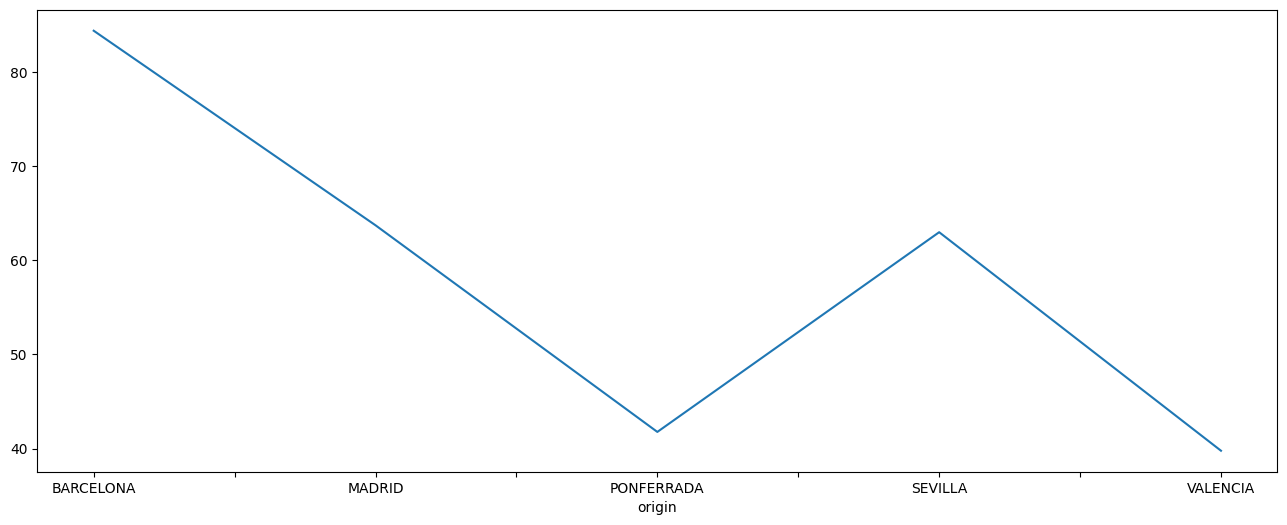

In [38]:
model_df.groupby("origin")["price"].mean().compute().plot(figsize=(16, 6))

<Axes: xlabel='destination'>

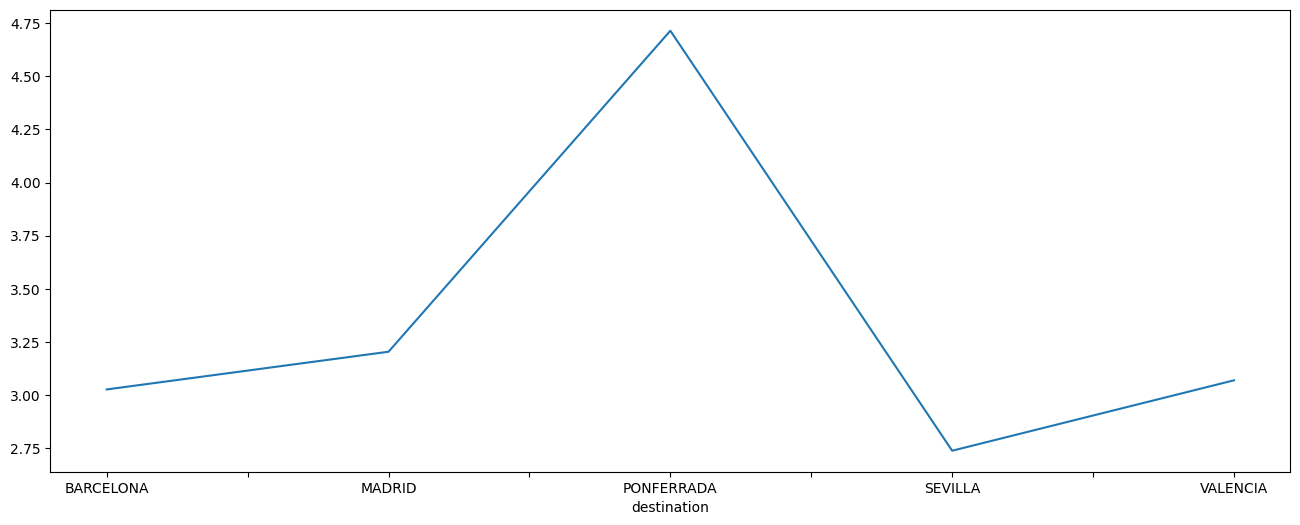

In [39]:
model_df.groupby("destination")["duration"].mean().compute().plot(figsize=(16, 6))

In [26]:
X = model_df_computed.drop(columns=["price"])
y = model_df_computed["price"]

cat_cols = ["origin", "destination"]
X[cat_cols] = X[cat_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42, enable_categorical=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 5.690
R²: 0.951
